# Mutual Fund Performance Analytics (2022–2026)

## Bluestock Fintech Internship – Day 4

### Objective

This notebook evaluates the risk and performance of 40 mutual fund schemes using quantitative finance metrics.

### Performance Metrics

- Daily Returns
- CAGR (1Y, 3Y, 5Y)
- Sharpe Ratio
- Sortino Ratio
- Alpha & Beta
- Maximum Drawdown
- Fund Scorecard
- Benchmark Comparison

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from scipy.stats import linregress

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

In [2]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

In [3]:
nav = nav.merge(
    fund_master[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["scheme_name","date"]
)

# 1. Daily Return Analysis

Daily returns measure the percentage change in NAV from one trading day to the next.

Formula:

Daily Return = NAV(t) / NAV(t-1) − 1

In [4]:
nav["daily_return"] = (
    nav.groupby("scheme_name")["nav"]
       .pct_change()
)

In [5]:
nav.head()

,amfi_code,date,nav,scheme_name,daily_return
3450,101206,2022-01-03,305.0996,ABSL Frontline Equity Fund - Regular - Growth,NaN
3451,101206,2022-01-04,305.4514,ABSL Frontline Equity Fund - Regular - Growth,0.001153
3452,101206,2022-01-05,306.6324,ABSL Frontline Equity Fund - Regular - Growth,0.003866
3453,101206,2022-01-06,305.9800,ABSL Frontline Equity Fund - Regular - Growth,-0.002128
3454,101206,2022-01-07,304.0480,ABSL Frontline Equity Fund - Regular - Growth,-0.006314


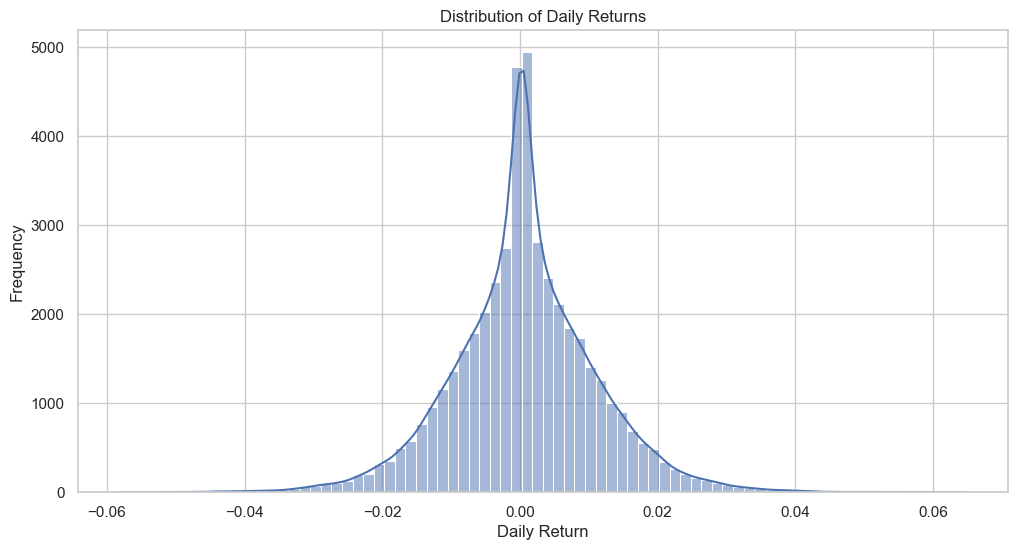

In [6]:
plt.figure(figsize=(12,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=80,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.show()

In [7]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

### Insight 1

The distribution of daily returns is centered close to zero, indicating that most NAV movements are relatively small, with occasional larger gains and losses during volatile market periods.

In [8]:
nav.head()

,amfi_code,date,nav,scheme_name,daily_return
3450,101206,2022-01-03,305.0996,ABSL Frontline Equity Fund - Regular - Growth,NaN
3451,101206,2022-01-04,305.4514,ABSL Frontline Equity Fund - Regular - Growth,0.001153
3452,101206,2022-01-05,306.6324,ABSL Frontline Equity Fund - Regular - Growth,0.003866
3453,101206,2022-01-06,305.9800,ABSL Frontline Equity Fund - Regular - Growth,-0.002128
3454,101206,2022-01-07,304.0480,ABSL Frontline Equity Fund - Regular - Growth,-0.006314


# 2. Compound Annual Growth Rate (CAGR)

Compound Annual Growth Rate (CAGR) measures the annualized growth rate of an investment over a specified time period.

Formula:

CAGR = (Ending NAV / Starting NAV)^(1/n) − 1

In [9]:
def calculate_cagr(df, years):
    results = []

    for scheme, group in df.groupby("scheme_name"):

        group = group.sort_values("date")

        end_date = group["date"].max()
        start_date = end_date - pd.DateOffset(years=years)

        period = group[group["date"] >= start_date]

        if len(period) < 2:
            continue

        start_nav = period.iloc[0]["nav"]
        end_nav = period.iloc[-1]["nav"]

        cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100

        results.append({
            "scheme_name": scheme,
            f"CAGR_{years}Y": cagr
        })

    return pd.DataFrame(results)

In [10]:
cagr_1 = calculate_cagr(nav, 1)
cagr_3 = calculate_cagr(nav, 3)
cagr_5 = calculate_cagr(nav, 5)

In [11]:
cagr = (
    cagr_1
    .merge(cagr_3, on="scheme_name")
    .merge(cagr_5, on="scheme_name")
)

cagr.head()

,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,ABSL Frontline Equity Fund - Regular - Growth,47.924120,28.967695,20.442730
1,ABSL Liquid Fund - Regular - Growth,7.236645,6.315784,5.705734
2,ABSL Small Cap Fund - Regular - Growth,-23.986032,-4.152381,6.953336
3,Axis Bluechip Fund - Direct - Growth,19.766741,20.816771,6.917406
4,Axis Bluechip Fund - Regular - Growth,1.609119,0.525887,5.582555


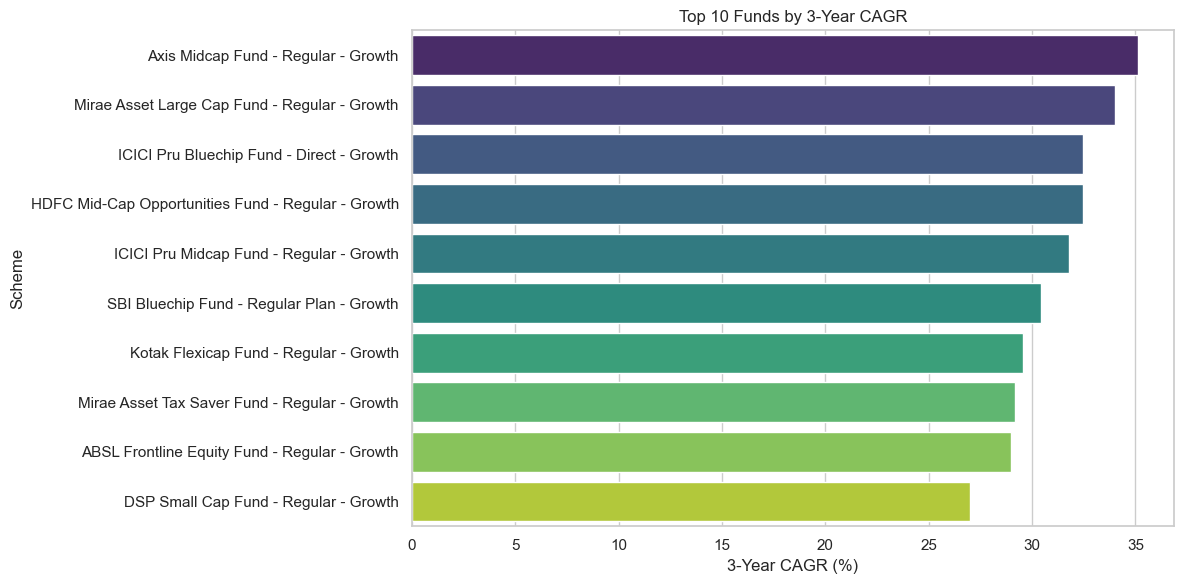

In [12]:
top10 = (
    cagr.sort_values(
        "CAGR_3Y",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="CAGR_3Y",
    y="scheme_name",
    palette="viridis"
)

plt.title("Top 10 Funds by 3-Year CAGR")

plt.xlabel("3-Year CAGR (%)")
plt.ylabel("Scheme")

plt.tight_layout()

plt.show()

### Insight 2

Several equity-oriented mutual funds delivered strong annualized returns over the three-year period, highlighting consistent long-term performance despite short-term market volatility.

In [13]:
cagr.describe()

,CAGR_1Y,CAGR_3Y,CAGR_5Y
count,40.000000,40.000000,40.000000
mean,19.428520,16.414715,14.541077
std,22.912276,12.206752,8.901844
min,-42.797615,-11.705807,1.030350
25%,7.377949,6.600925,6.013784
50%,17.474125,18.233102,14.476118
75%,27.161651,26.902600,21.257057
max,82.776059,35.111802,28.376762


# 3. Sharpe Ratio

The Sharpe Ratio measures the risk-adjusted return of a mutual fund.

Formula:

Sharpe Ratio = (Rp − Rf) / σ × √252

Where:

- Rp = Average Daily Return
- Rf = Risk-Free Rate (6.5%)
- σ = Standard Deviation of Daily Returns

In [14]:
risk_free_rate = 0.065
daily_rf = risk_free_rate / 252

In [15]:
sharpe = (
    nav.groupby("scheme_name")["daily_return"]
       .agg(["mean", "std"])
       .reset_index()
)

sharpe["Sharpe Ratio"] = (
    (sharpe["mean"] - daily_rf)
    / sharpe["std"]
) * np.sqrt(252)

In [16]:
sharpe = sharpe.sort_values(
    "Sharpe Ratio",
    ascending=False
)

sharpe.head(10)

,scheme_name,mean,std,Sharpe Ratio
25,Mirae Asset Large Cap Fund - Regular - Growth,0.001074,0.008941,1.448291
22,Kotak Flexicap Fund - Regular - Growth,0.001082,0.010008,1.306744
26,Mirae Asset Tax Saver Fund - Regular - Growth,0.001124,0.011134,1.234930
33,SBI Bluechip Fund - Regular Plan - Growth,0.000917,0.008656,1.208267
18,ICICI Pru Midcap Fund - Regular - Growth,0.001161,0.012152,1.180101
7,DSP Midcap Fund - Regular - Growth,0.001055,0.011179,1.132122
11,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.001080,0.011929,1.093699
30,Nippon India Large Cap Fund - Regular - Growth,0.000865,0.008913,1.081659
0,ABSL Frontline Equity Fund - Regular - Growth,0.000852,0.009177,1.027213
15,ICICI Pru Bluechip Fund - Direct - Growth,0.000843,0.009048,1.026524


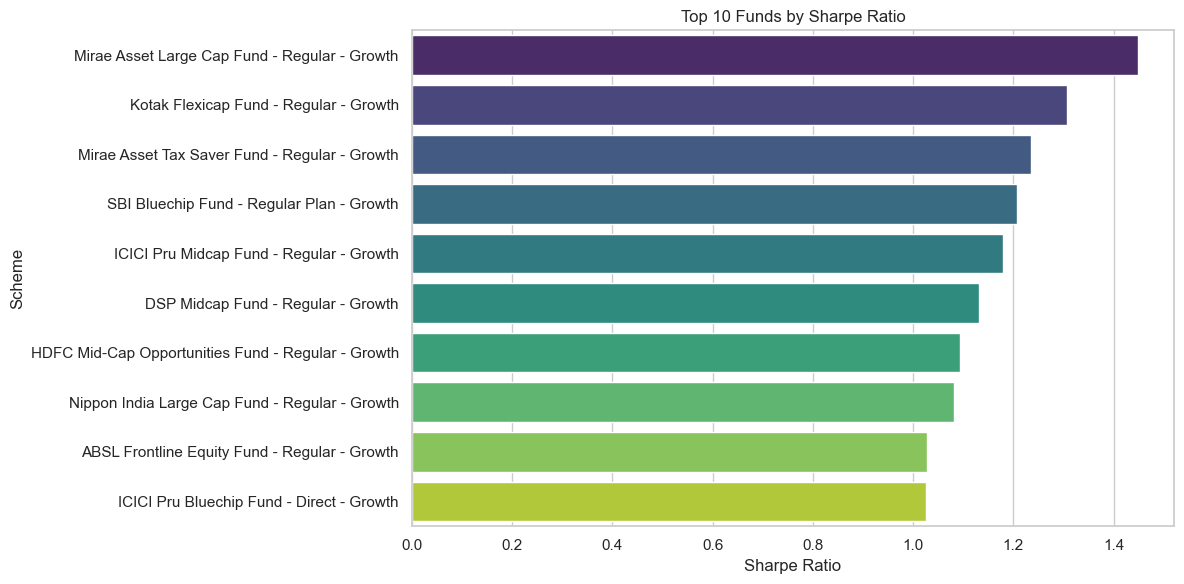

In [17]:
top10 = sharpe.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="Sharpe Ratio",
    y="scheme_name",
    palette="viridis"
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.xlabel("Sharpe Ratio")
plt.ylabel("Scheme")

plt.tight_layout()

plt.show()

### Insight 3

Funds with higher Sharpe Ratios generated superior risk-adjusted returns, indicating they delivered better returns for each unit of risk undertaken.

In [18]:
sharpe.describe()

,mean,std,Sharpe Ratio
count,40.000000,40.000000,40.000000
mean,0.000631,0.009414,0.537220
std,0.000348,0.004205,0.573689
min,0.000110,0.000311,-0.815567
25%,0.000273,0.008724,0.064696
50%,0.000648,0.009171,0.647043
75%,0.000878,0.011458,1.005304
max,0.001201,0.016251,1.448291


# 4. Sortino Ratio

The Sortino Ratio measures risk-adjusted returns by considering only downside volatility.

Formula:

Sortino Ratio = (Rp − Rf) / Downside Deviation × √252

In [19]:
risk_free_rate = 0.065
daily_rf = risk_free_rate / 252

sortino_results = []

for scheme, group in nav.groupby("scheme_name"):

    returns = group["daily_return"].dropna()

    downside = returns[returns < 0]

    downside_std = downside.std()

    mean_return = returns.mean()

    if downside_std == 0 or np.isnan(downside_std):
        sortino = np.nan
    else:
        sortino = ((mean_return - daily_rf) / downside_std) * np.sqrt(252)

    sortino_results.append({
        "scheme_name": scheme,
        "Sortino Ratio": sortino
    })

sortino = pd.DataFrame(sortino_results)

sortino = sortino.sort_values(
    "Sortino Ratio",
    ascending=False
)

sortino.head(10)

,scheme_name,Sortino Ratio
25,Mirae Asset Large Cap Fund - Regular - Growth,2.385644
22,Kotak Flexicap Fund - Regular - Growth,2.364320
26,Mirae Asset Tax Saver Fund - Regular - Growth,2.146914
33,SBI Bluechip Fund - Regular Plan - Growth,2.140267
18,ICICI Pru Midcap Fund - Regular - Growth,2.029353
7,DSP Midcap Fund - Regular - Growth,1.875101
30,Nippon India Large Cap Fund - Regular - Growth,1.850133
11,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.829134
15,ICICI Pru Bluechip Fund - Direct - Growth,1.805294
0,ABSL Frontline Equity Fund - Regular - Growth,1.799563


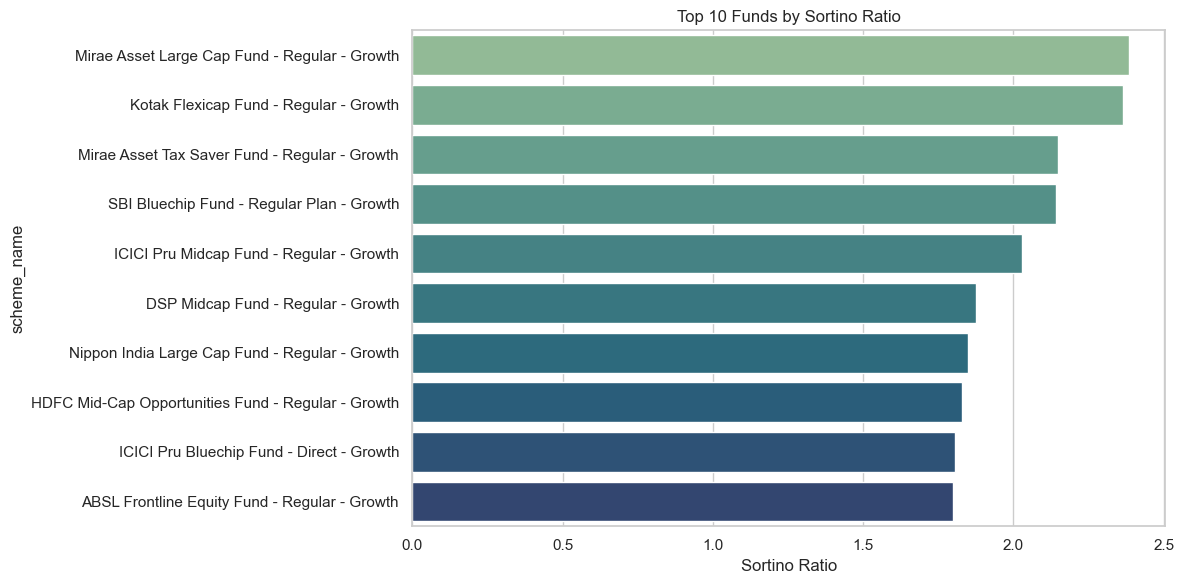

In [20]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=sortino.head(10),
    x="Sortino Ratio",
    y="scheme_name",
    palette="crest"
)

plt.title("Top 10 Funds by Sortino Ratio")

plt.tight_layout()

plt.show()

In [21]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='object')

In [22]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

nifty100 = benchmark[
    benchmark["index_name"].str.contains(
        "Nifty 100",
        case=False
    )
]

In [ ]:
nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15
